In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

CHECKING DEVICE (GPU/CPU)

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Mounting Google Drive

In [ ]:
assert 'cuda' in repr(device), "GPU is not selected in hardware accelerator dropdown"

# This assertion checks if the string "cuda" is present in the Representation of
# the object 'device' or not. If not, then it raises Assertion Error


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
# ! mkdir /content/drive/MyDrive/Checkpoints1

# Using this command we grant this notebook access to the google drive and create a directory inside drive where we will store the weights of
# the neural network after training is completed


Mounted at /content/drive


In [ ]:
path1 = "/content/drive/MyDrive/Checkpoints1" # Path to the directory created in drive
assert os.path.isdir(path1), f"{path1} is not a valid location"

# The above line checks whether the path stored in variable path1 is actually the location of a real directory. If not then program execution
# will stop due to Assertion Error

# Neural Network

NEURAL NETWORK DEFINITION AND INITIALIZATION

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# Defining custom neural network in the class Net

class Net(nn.Module):
  def __init__(self): # In this function the layers of the neural network are initialized. Self is the current instance of the class
    super().__init__() # It is a way to call a method from the parent class, which in nn.module

    self.conv1 = nn.Conv2d(1,64,3,1,padding=1) # This defines the first convolution layer that has 3 Input Channels, 16 Output Channels
                                     # the size of Kernel used is 3X3 and thus the Padding given is 1
    self.conv2 = nn.Conv2d(64,128,3,1,padding=1) # This defines the second convolution layer, whose input channel = output channel of first layer
    self.conv3 = nn.Conv2d(128,128,3,1,padding=1) # This defines the third convolution layer, whose input channel = output channel of second layer
    self.conv4 = nn.Conv2d(128,128,3,1,padding=1)
    self.conv5 = nn.Conv2d(128,256,3,1,padding=1)
    self.conv6 = nn.Conv2d(256,512,3,1,padding=1)
    self.conv7 = nn.Conv2d(512,512,3,1,padding=1)
    self.conv8 = nn.Conv2d(512,512,3,1,padding=1)
    self.m = nn.Conv2d(128,512,1,1)

    self.fc_out = nn.Linear(512*28*28,10) # This defines a fully connected layer having input nodes = 64 and output nodes = 10
                                # which is equal to the number of class labels

  def forward(self,x):
    x = F.relu(self.conv1(x))
    x = F.relu(self.conv2(x))
    residue = x

    x = F.relu(self.conv3(x))
    x = F.relu(self.conv4(x))
    x = x + residue
    residue = x

    x = F.relu(self.conv5(x))
    x = F.relu(self.conv6(x))
    residue = self.m(residue)
    x = x + residue
    residue = x

    x = F.relu(self.conv7(x))
    x = F.relu(self.conv8(x))
    x = x + residue

    x = torch.flatten(x,1)
    x = self.fc_out(x)
    return(nn.Softmax(1)(x))

model = Net().to(device) # An instance of the neural network defined in the class Net, called model is transferred to the device
                         # which is either cude:0 (GPU) or cpu

LOSS FUNCTION AND OPTIMIZER DEFINITION

In [ ]:
loss_func = nn.CrossEntropyLoss() # Cross Entropy Loss function is used for training the neural network
optimizer = torch.optim.SGD(model.parameters(),0.0002,0.9) # Stochastic Gradient Descent optimizer is used

LOADING THE DATA

In [ ]:
import torchvision
import torchvision.transforms as transforms

tr = transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.5,) ,(0.5,))])
# This command creates a sequence of operations to be applied on the image data from CIFAR10
# .Compose() takes the list of transformations and applies them sequentially
# .ToTensor() will convert the PIL image or numpy array into Pytorch Tensor and scales the pixel values from [0,1]
# .Normalize() will normalize the tensor image with the given mean = 0.5 and standard deviation = 0.5 for each input channel

batch_size = 16

train_set = torchvision.datasets.MNIST(root = './data', train = True, download = True, transform = tr)
test_set = torchvision.datasets.MNIST(root = './data', train = False, download = True, transform = tr)
# The program downloads CIFAR10 data from the torchvision library

train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle = True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size, shuffle = True, num_workers = 2)

# This function creates a Dataloader object for training data, called train_loader and for testing
# data called test_loader. This object is used to iterated through the data during training and testing.
# It is also responsible for efficiently loading and batching the data. Training data is shuffled before
# each epoch. Also 2 parallel worker processes are used to load data.

class_labels = ('0','1','2','3','4','5','6','7','8','9')

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 9.91M/9.91M [00:02<00:00, 4.59MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 28.9k/28.9k [00:00<00:00, 135kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
<urlopen error [Errno 111] Connection refused>



100%|██████████| 4.54k/4.54k [00:00<00:00, 3.83MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



VALIDATOR CODE

In [ ]:
# It validates the neural network on test dataset
def validator(testloader = None, net = None):
  correct_pred = 0
  total_pred = 0

  with torch.no_grad():
    for data in (testloader):
      image,label = data
      image = image.to(device)
      label = label.to(device)

      output = net(image)
      val,predicted = torch.max(output.data,1) # Val is the maximum value and predicted is the index where it is found
      total_pred += label.size(0)
      correct_pred += (predicted==label).sum().item()

  print(f'Accuracy of the network on the 10000 test images: {100 * correct_pred // total_pred} %')
  return correct_pred/total_pred

TRAINING THE NETWORK

In [ ]:
import torch
best_accuracy = -1

for epoch in range(10):
  r_loss = 0 # Stores the loss for the current epoch
  for i,data in enumerate(train_loader,0):
    input,label = data
    input = input.to(device) # Transferring the input data to GPU/CPU
    label = label.to(device) # Transferring the labels to GPU/CPU

    optimizer.zero_grad() # Initialize the gradient value to 0

    output = model(input)
    loss = loss_func(output,label)
    loss.backward() # It will calculate the gradients and accumulate them
    optimizer.step() # It will update the parameters, i.e weights and bias

    r_loss += loss.item()
    if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {r_loss / 2000:.3f}')
            r_loss = 0

  accuracy = validator(test_loader,model) # Validator function accepts the testloader object and the neural network
  if accuracy > best_accuracy:
        best_accuracy = accuracy

        torch.save(
            {'epoch':epoch,
             'model_state_dict': model.state_dict(),
             'optimizer_state_dict': optimizer.state_dict()
             },

             path1 +'best_model.pth')

  #Save model as checkpoint
  torch.save(
        {'epoch':epoch,
         'model_state_dict': model.state_dict(),
         'optimizer_state_dict': optimizer.state_dict()
         },
         path1 +'checkpoint.pth')



print('Finished Training')

[1,  2000] loss: 1.614
Accuracy of the network on the 10000 test images: 85 %
[2,  2000] loss: 1.607
Accuracy of the network on the 10000 test images: 86 %
[3,  2000] loss: 1.602
Accuracy of the network on the 10000 test images: 86 %
[4,  2000] loss: 1.597
Accuracy of the network on the 10000 test images: 87 %
[5,  2000] loss: 1.592
Accuracy of the network on the 10000 test images: 87 %
[6,  2000] loss: 1.586
Accuracy of the network on the 10000 test images: 87 %
[7,  2000] loss: 1.582
Accuracy of the network on the 10000 test images: 88 %
[8,  2000] loss: 1.578
Accuracy of the network on the 10000 test images: 88 %
[9,  2000] loss: 1.510
Accuracy of the network on the 10000 test images: 96 %
[10,  2000] loss: 1.490
Accuracy of the network on the 10000 test images: 97 %
Finished Training


TESTING THE NETWORK

In [ ]:
data_iter = iter(test_loader)
image, label = next(data_iter)

model_best = Net().to(device)
checkpoint = torch.load(path1+'best_model.pth')
model_best.load_state_dict(checkpoint['model_state_dict'])


images = image.to(device)
labels = label.to(device)

output = model_best(images)
_, predicted = torch.max(output, 1)

print('Predicted: ', ' '.join(f'{class_labels[predicted[j]]:5s}'
                              for j in range(len(predicted))))

print('GroundTruth: ', ' '.join(f'{class_labels[labels[j]]:5s}' for j in range(batch_size)))

<ipython-input-31-69a74fc8f449>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path1+'best_model.pth')


Predicted:  2     2     7     7     0     6     7     5     3     0     3     1     7     6     9     7    
GroundTruth:  2     2     7     7     0     6     7     5     3     0     3     1     7     6     9     7    


TO FIND CLASSWISE ACCURACY

In [ ]:
# It validates the neural network on test dataset
def classwise_validator(testloader = None, net = None, classes = None):
  correct_pred = {classname:0 for classname in classes}
  total_pred = {classname:0 for classname in classes}

# This creates a dictionary in which the correct predictions corresponding to each class label will be stored as key-value pair

  with torch.no_grad():
    for data in (testloader):
      image,labels = data
      image = image.to(device)
      labels = labels.to(device)

      output = net(image)
      _, predictions = torch.max(output, 1)
      for label,prediction in zip(labels,predictions):
        if(label==prediction):
          correct_pred[classes[label]] += 1
        total_pred[classes[label]] += 1

  for classname, correct_count in correct_pred.items():
    if(total_pred[classname]>0):
      accuracy = 100 * float(correct_count) / total_pred[classname]
      print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

  return

In [ ]:
classwise_validator(test_loader,model_best,class_labels)

Accuracy for class: 0     is 98.6 %
Accuracy for class: 1     is 98.7 %
Accuracy for class: 2     is 85.9 %
Accuracy for class: 3     is 92.7 %
Accuracy for class: 4     is 92.3 %
Accuracy for class: 5     is 0.0 %
Accuracy for class: 6     is 96.8 %
Accuracy for class: 7     is 93.6 %
Accuracy for class: 8     is 88.9 %
Accuracy for class: 9     is 93.1 %


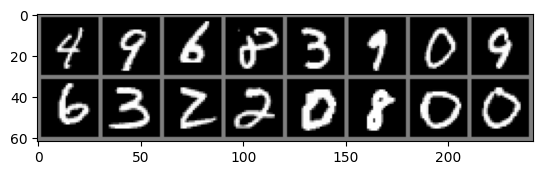

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize, range 0 to 1
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images)) #flattening the image
# print labels
# print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))#mapping the label j to class